In [2]:
import xarray as xr 
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
may1 = xr.open_dataset('/nfs/gce/projects/crocus/data/ingested-data/ai-dt/min/crocus_micronet_merged_20250506.v1.nc')
may2 = xr.open_dataset('/nfs/gce/projects/crocus/data/ingested-data/ai-dt/min/crocus_micronet_merged_20250507.v1.nc')
ds = may1.combine_first(may2)

In [3]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:        (site: 11, time: 2880)
Coordinates:
  * time           (time) datetime64[ns] 23kB 2025-05-06 ... 2025-05-07T23:59:00
  * site           (site) <U5 220B 'NU' 'CSU' 'NEIU' ... 'DOWN' 'SHEDD' 'VILLA'
Data variables: (12/20)
    temperature    (site, time) float64 253kB 11.0 11.0 10.92 ... 11.92 11.9
    humidity       (site, time) float64 253kB 81.35 81.3 81.75 ... 55.6 55.44
    pressure       (site, time) float64 253kB 993.4 993.4 993.4 ... 992.2 992.1
    rainfall       (site, time) float64 253kB 123.9 123.9 123.9 ... 230.3 230.3
    dewpoint       (site, time) float64 253kB 7.93 7.921 7.929 ... 3.321 3.261
    wetbulb        (site, time) float64 253kB 9.316 9.311 9.282 ... 7.596 7.561
    ...             ...
    no2            (site, time) float64 253kB nan nan nan ... 0.008 0.008
    co             (site, time) float64 253kB nan nan nan ... 0.034 0.02867
    latitude       (site) float64 88B 42.05 41.72 41.98 ... 41.8 41.87 41.88
    longitude      (site) float64 88B -87.68 -87.61 -87.72 ... -87.61 -87.98
    wsn            (site) <U4 176B 'W099' 'W08E' 'W08D' ... 'W09D' 'W09E' 'W095'
    elevation      (site) float64 88B 21.5 0.0 13.25 0.0 ... -999.0 14.41 8.5
Attributes:
    convention:         CF 1.10
    datalevel:          b1
    history:            created by obrienj at 2025-10-24T15:12:00Z on compute...
    input_datastreams:  Vaisala WXT and Vaisala AQT
    contact:            email questions to obrienj@anl.gov
    comments:           This is an initial evaluation product. Use with Caution.


Detections (chronological, Central time):
2025-05-06 14:00 CDT: SHEDD  (min drop -3.1°C)
2025-05-06 14:30 CDT: NU  (min drop -4.3°C)
2025-05-06 15:00 CDT: CCICS  (min drop -2.7°C)
2025-05-07 11:30 CDT: SHEDD  (min drop -3.1°C)
2025-05-07 12:00 CDT: BIG  (min drop -3.2°C)
2025-05-07 12:30 CDT: VILLA  (min drop -3.2°C)
2025-05-07 13:00 CDT: DOWN  (min drop -2.9°C)


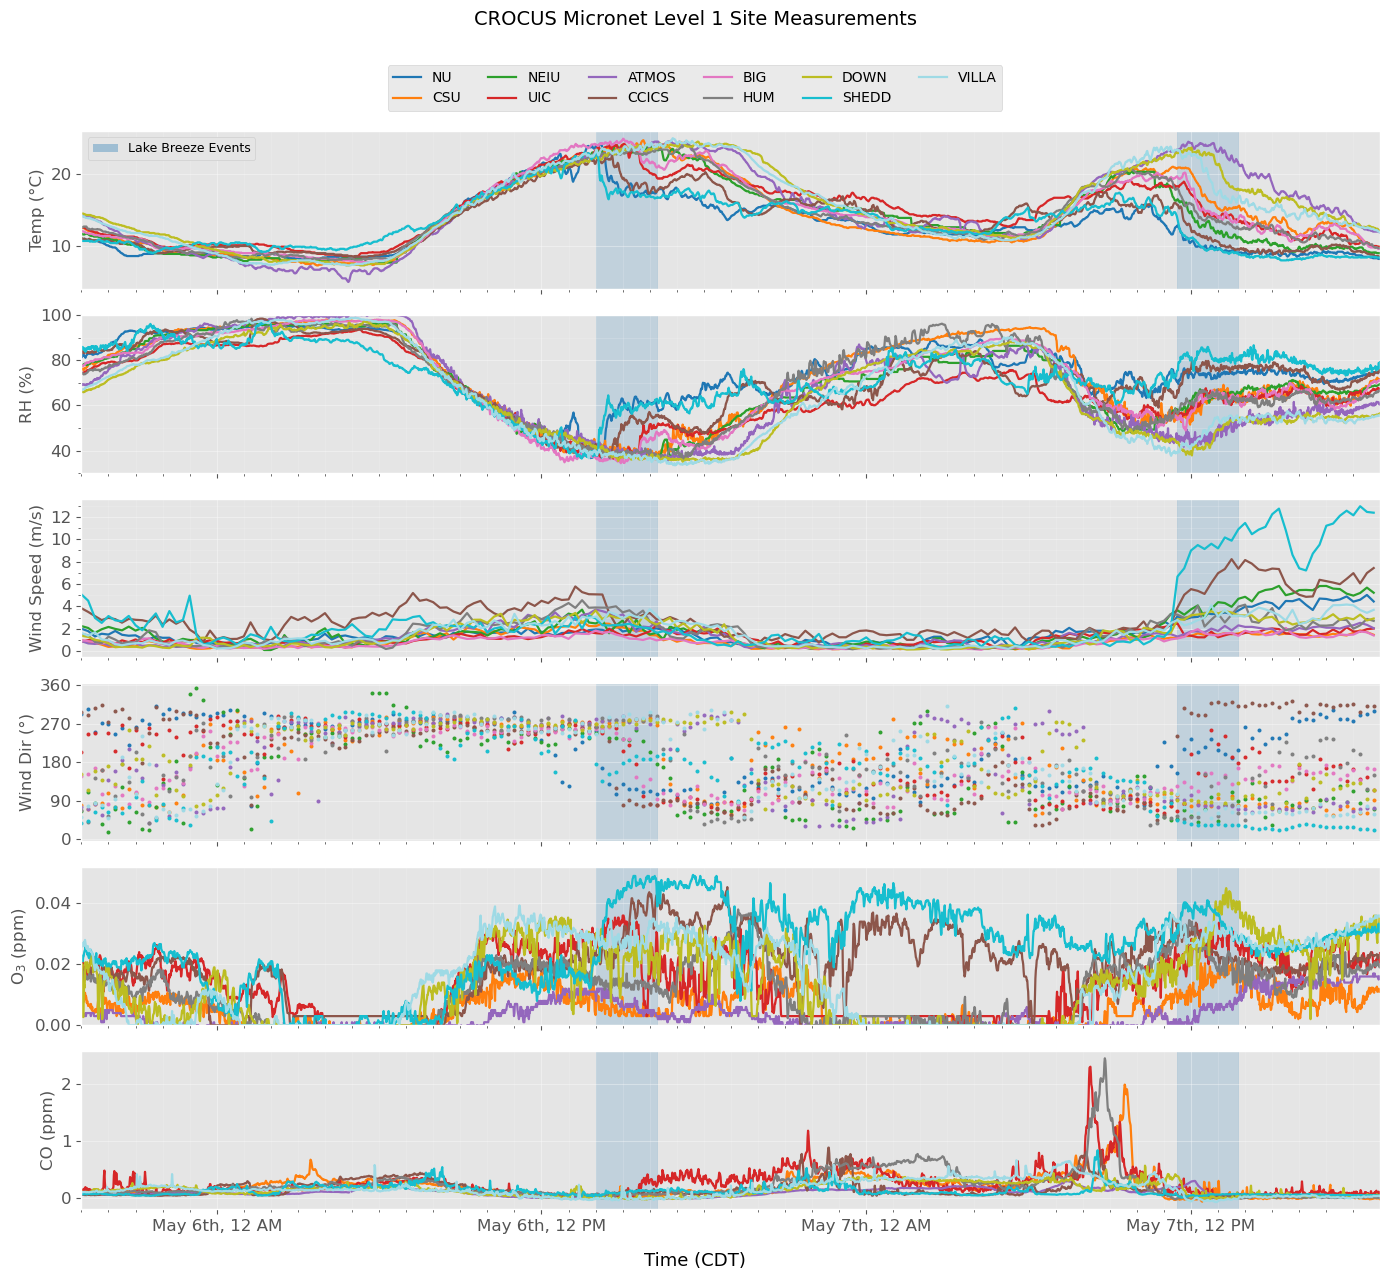

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.patches import Patch
from zoneinfo import ZoneInfo  # Python 3.9+
import pandas as pd

# ds = xr.open_dataset("your_file.nc")  # if not already open
plt.style.use('ggplot')

# --- Resampling: ONLY wind gets scalar means (your intervals) ---
spd20  = ds["wind_mean_10s"].resample(time="15min").mean()
wdir15 = ds["wind_dir_10s"].resample(time="15min").mean()

# Temperature, RH, O3, CO at native resolution
temp = ds["temperature"]
rh   = ds["humidity"]
o3   = ds["o3"]
co   = ds["co"]

# --- Build Central time indices (assumes source time is UTC or naive-UTC) ---
def to_central_index(xr_time):
    idx = xr_time.to_index()
    if idx.tz is None:
        idx = idx.tz_localize("UTC")
    return idx.tz_convert("America/Chicago")

t_time    = to_central_index(temp.time)
rh_time   = to_central_index(rh.time)
o3_time   = to_central_index(o3.time)
co_time   = to_central_index(co.time)
spd_time  = to_central_index(spd20.time)
wdir_time = to_central_index(wdir15.time)

# --- Global time bounds (actual data span) ---
idx_list = [
    i for i in [t_time, rh_time, o3_time, co_time, spd_time, wdir_time]
    if len(i) > 0
]
t_min = min(i.min() for i in idx_list)
t_max = max(i.max() for i in idx_list)

# --- Color map for sites (consistent color across panels) ---
sites = list(ds.site.values)
sites = [s.item() if hasattr(s, "item") else s for s in sites]
n_sites = len(sites)

if n_sites <= 20:
    cmap_sites = plt.get_cmap("tab20", n_sites)
    site_color = {s: cmap_sites(i) for i, s in enumerate(sites)}
else:
    cmap_sites = plt.get_cmap("viridis")
    norm_sites = mpl.colors.Normalize(vmin=0, vmax=max(1, n_sites - 1))
    site_color = {s: cmap_sites(norm_sites(i)) for i, s in enumerate(sites)}

# --- Plot: 6 stacked panels, ALL SITES overlaid on each panel ---
# Order: Temp, RH, Wind Speed, Wind Dir, O3, CO
fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
axT, axRH, axWS, axWD, axO3, axCO = axes

handles, labels = [], []
for s in ds.site.values:
    s_key = s.item() if hasattr(s, "item") else s
    color = site_color[s_key]

    ln, = axT.plot(t_time,  temp.sel(site=s).to_numpy(), lw=1.6, color=color)
    axRH.plot(rh_time,     rh.sel(site=s).to_numpy(),    lw=1.6, color=color)
    axWS.plot(spd_time,    spd20.sel(site=s).to_numpy(), lw=1.6, color=color)
    axWD.plot(
        wdir_time, wdir15.sel(site=s).to_numpy(),
        linestyle="None", marker=".", markersize=3.8,
        color=color, alpha=0.95
    )
    axO3.plot(o3_time,     o3.sel(site=s).to_numpy(),    lw=1.6, color=color)
    axCO.plot(co_time,     co.sel(site=s).to_numpy(),    lw=1.6, color=color)

    handles.append(ln)
    labels.append(str(s_key))

# Exact bounds + no padding
for ax in axes:
    ax.set_xlim(t_min, t_max)
    ax.margins(x=0)

# ---------- Major ticks ONLY at 12 AM and 12 PM (local), minors hourly ----------
tz_central = ZoneInfo("America/Chicago")
major_loc = mdates.HourLocator(byhour=[0, 12], tz=tz_central)   # labeled
minor_loc = mdates.HourLocator(interval=1, tz=tz_central)       # unlabeled grid

# ---------- Formatter: CDT only (no UTC) ----------
def _ordinal(n: int) -> str:
    if 10 <= n % 100 <= 13:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

def cdt_formatter(x, pos):
    dt_loc = mdates.num2date(x, tz=tz_central)
    mon    = dt_loc.strftime("%b")
    day    = _ordinal(dt_loc.day)
    hr12   = (dt_loc.hour % 12) or 12
    ampm   = "AM" if dt_loc.hour < 12 else "PM"
    return f"{mon} {day}, {hr12} {ampm}"

fmt_major = FuncFormatter(cdt_formatter)

for ax in axes:
    ax.xaxis.set_major_locator(major_loc)
    ax.xaxis.set_minor_locator(minor_loc)
    ax.xaxis.set_major_formatter(fmt_major)
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.15)
    ax.tick_params(labelsize=12)

# -------- Y axes --------
axT.set_ylabel("Temp (°C)", fontsize=12)

axRH.set_ylabel("RH (%)", fontsize=12)
axRH.set_ylim(30, 100)
axRH.yaxis.set_major_locator(MultipleLocator(20))
axRH.yaxis.set_minor_locator(MultipleLocator(10))

axWS.set_ylabel("Wind Speed (m/s)", fontsize=12)  # units per dataset
axWS.yaxis.set_major_locator(MultipleLocator(2))
axWS.yaxis.set_minor_locator(MultipleLocator(1))
axWS.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

axWD.set_ylabel("Wind Dir (°)", fontsize=12)
axWD.set_yticks([0, 90, 180, 270, 360])
axWD.set_ylim(-5, 365)

# O3 / CO labels in ppm, O3 starts at 0
axO3.set_ylabel("O$_3$ (ppm)", fontsize=12)
axO3.set_ylim(bottom=0)

axCO.set_ylabel("CO (ppm)", fontsize=12)

# Centered x-label
fig.supxlabel("Time (CDT)", fontsize=13)

# Legend + title (site legend)
fig.legend(handles, labels, ncol=min(6, len(labels)), loc="upper center",
           bbox_to_anchor=(0.5, 1.02), fontsize=10)
fig.suptitle("CROCUS Micronet Level 1 Site Measurements",
             fontsize=14, y=1.06)

# ================== Detect ≥2.5°C drops over 30 minutes ==================
TEMP_DROP_C = 2.5  # threshold

# 1) Resample temperature to 30-min means
temp30 = temp.resample(time="30min").mean(skipna=True)

# 2) Consecutive 30-min change (end - start); drops are negative
dtemp30 = temp30.diff("time")

# 3) Keep only drops whose magnitude is ≥ TEMP_DROP_C (i.e., <= -2.5)
drops = dtemp30.where(dtemp30 <= -TEMP_DROP_C)

# 4) Build events table (UTC + Central) with magnitudes, then print chronologically
events = []
for s in temp30.site.values:
    s_key = s.item() if hasattr(s, "item") else s
    sel = drops.sel(site=s).dropna("time", how="any")  # DataArray of drops ≤ -TEMP_DROP_C
    if sel.size == 0:
        continue

    utc_idx = sel.time.to_index()
    if utc_idx.tz is None:
        utc_idx = utc_idx.tz_localize("UTC")

    for t_utc, mag in zip(utc_idx, sel.values):
        t_loc = t_utc.tz_convert("America/Chicago")
        events.append({
            "site": str(s_key),
            "time_utc": t_utc,
            "time_central": t_loc,
            "drop_C": float(mag)  # negative value
        })

events_df = pd.DataFrame(events).sort_values(
    ["time_central", "site"]
).reset_index(drop=True)

# ------- PRINT: chronological occurrences (Central time), grouped by time -------
if events_df.empty:
    print("\nNo detections found.")
else:
    print("\nDetections (chronological, Central time):")
    for t_loc, grp in events_df.groupby("time_central"):
        sites_str = ", ".join(grp["site"])
        max_drop = grp["drop_C"].min()  # most negative is largest drop
        print(f"{t_loc.strftime('%Y-%m-%d %H:%M %Z')}: "
              f"{sites_str}  (min drop {max_drop:.1f}°C)")

# 5) SHADED WINDOWS per local day: same-length windows
if not events_df.empty:
    # group by local *date*
    day_groups = events_df.groupby(events_df["time_central"].dt.date).agg(
        start=("time_central", "min"),
        end=("time_central", "max"),
    )
    # extend end by +45 minutes (buffer)
    day_groups["end"] = day_groups["end"] + pd.Timedelta(minutes=45)

    # common window = longest day window
    window_lengths = day_groups["end"] - day_groups["start"]
    common_window = window_lengths.max()

    BLUE  = "#1f77b4"
    day_dates = sorted(day_groups.index)  # chronological

    # draw shaded spans on ALL axes using same length for each day
    for d in day_dates:
        start = day_groups.loc[d, "start"]
        end   = start + common_window
        for ax in axes:
            ax.axvspan(start, end, color=BLUE, alpha=0.18, zorder=0)

    # single legend patch explaining shaded windows
    lb_patch = Patch(facecolor=BLUE, alpha=0.35, edgecolor="none",
                     label="Lake Breeze Events")
    axT.legend(handles=[lb_patch], loc="upper left",
               fontsize=9, framealpha=0.9)

# =====================================================================
fig.tight_layout()
plt.show()



Combined events (30-min intervals) where temp drops ≥2.0°C AND wind-direction shift is 45–120° (chronological, Central time):
2025-05-06 14:00 CDT: SHEDD  (min drop -3.1°C, max |Δdir| 85°)
2025-05-06 14:30 CDT: NU  (min drop -4.3°C, max |Δdir| 93°)
2025-05-06 15:00 CDT: CCICS  (min drop -2.7°C, max |Δdir| 90°)
2025-05-06 15:30 CDT: BIG  (min drop -2.0°C, max |Δdir| 100°)
2025-05-07 12:00 CDT: UIC  (min drop -2.2°C, max |Δdir| 103°)

Shaded lake-breeze bars (plot extents):
2025-05-06: 2025-05-06 14:00 CDT  →  2025-05-06 16:15 CDT  (duration 0 days 02:15:00)
2025-05-07: 2025-05-07 12:00 CDT  →  2025-05-07 14:15 CDT  (duration 0 days 02:15:00)


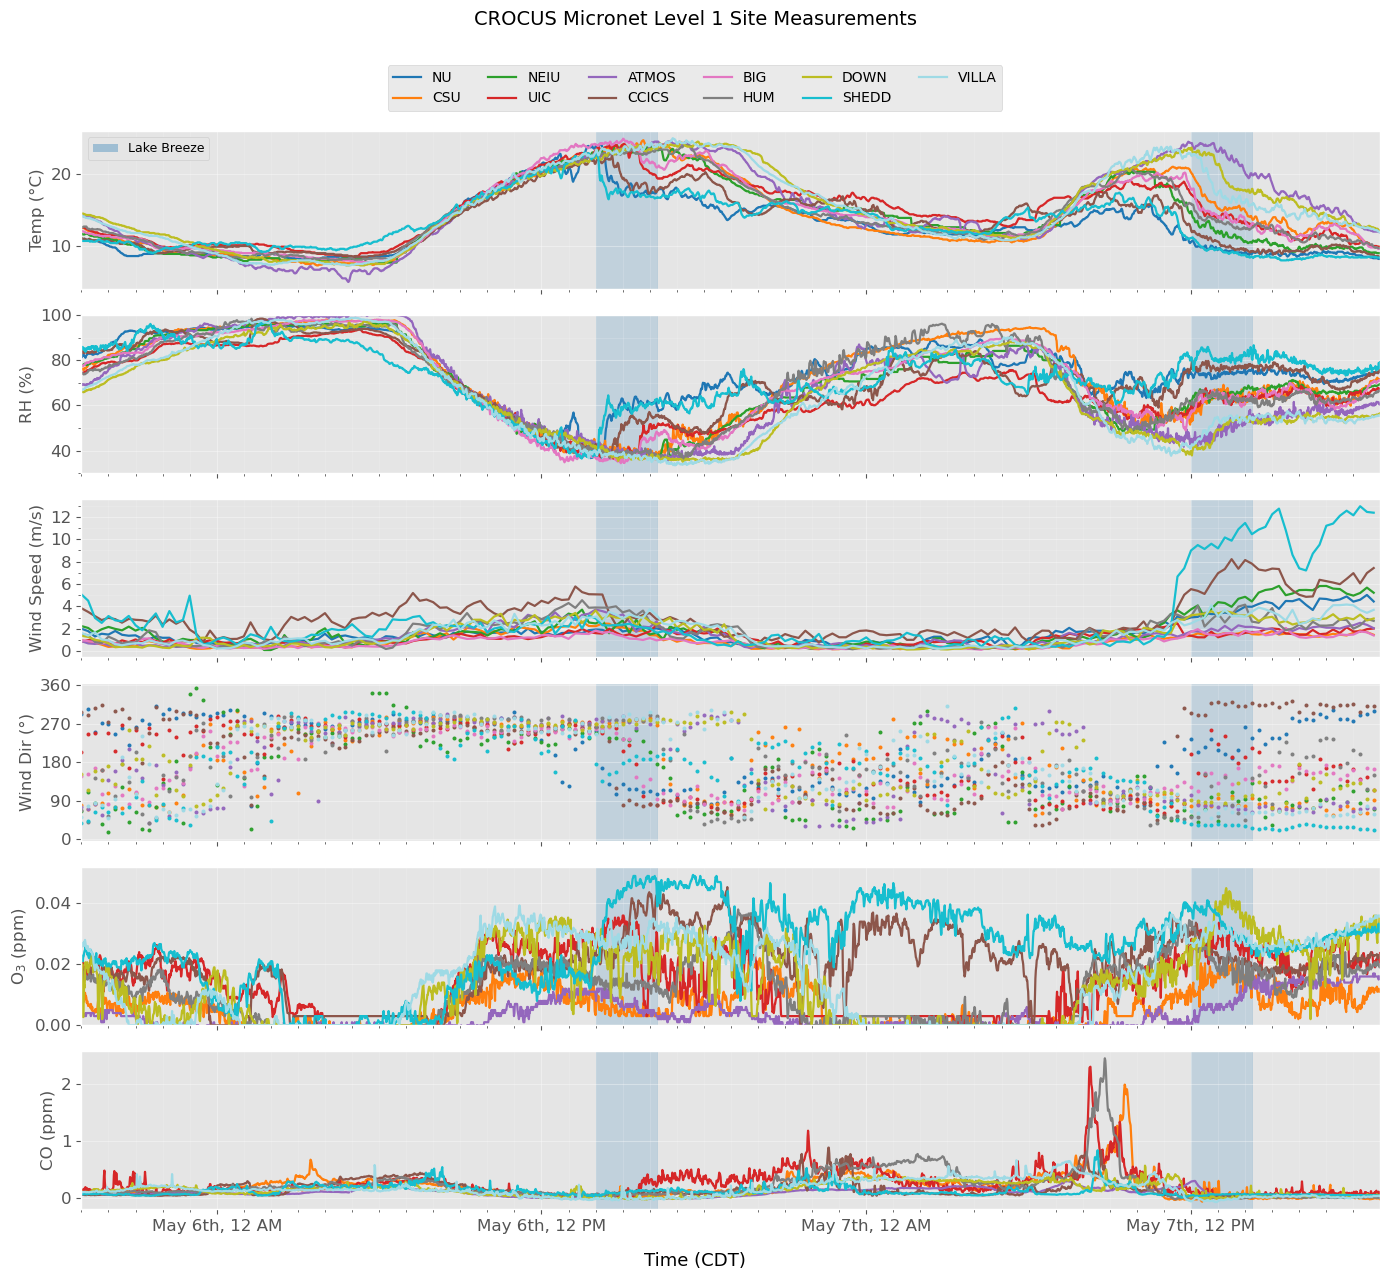

In [18]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.patches import Patch
from zoneinfo import ZoneInfo  # Python 3.9+
import pandas as pd

# ds = xr.open_dataset("your_file.nc")  # if not already open
plt.style.use('ggplot')

# --- Resampling: ONLY wind gets scalar means (your intervals) ---
spd20  = ds["wind_mean_10s"].resample(time="15min").mean()
wdir15 = ds["wind_dir_10s"].resample(time="15min").mean()

# Temperature, RH, O3, CO at native resolution
temp = ds["temperature"]
rh   = ds["humidity"]
o3   = ds["o3"]
co   = ds["co"]

# --- Build Central time indices (assumes source time is UTC or naive-UTC) ---
def to_central_index(xr_time):
    idx = xr_time.to_index()
    if idx.tz is None:
        idx = idx.tz_localize("UTC")
    return idx.tz_convert("America/Chicago")

t_time    = to_central_index(temp.time)
rh_time   = to_central_index(rh.time)
o3_time   = to_central_index(o3.time)
co_time   = to_central_index(co.time)
spd_time  = to_central_index(spd20.time)
wdir_time = to_central_index(wdir15.time)

# --- Global time bounds (actual data span) ---
idx_list = [
    i for i in [t_time, rh_time, o3_time, co_time, spd_time, wdir_time]
    if len(i) > 0
]
t_min = min(i.min() for i in idx_list)
t_max = max(i.max() for i in idx_list)

# --- Color map for sites (consistent color across panels) ---
sites = list(ds.site.values)
sites = [s.item() if hasattr(s, "item") else s for s in sites]
n_sites = len(sites)

if n_sites <= 20:
    cmap_sites = plt.get_cmap("tab20", n_sites)
    site_color = {s: cmap_sites(i) for i, s in enumerate(sites)}
else:
    cmap_sites = plt.get_cmap("viridis")
    norm_sites = mpl.colors.Normalize(vmin=0, vmax=max(1, n_sites - 1))
    site_color = {s: cmap_sites(norm_sites(i)) for i, s in enumerate(sites)}

# --- Plot: 6 stacked panels, ALL SITES overlaid on each panel ---
# Order: Temp, RH, Wind Speed, Wind Dir, O3, CO
fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
axT, axRH, axWS, axWD, axO3, axCO = axes

handles, labels = [], []
for s in ds.site.values:
    s_key = s.item() if hasattr(s, "item") else s
    color = site_color[s_key]

    ln, = axT.plot(t_time,  temp.sel(site=s).to_numpy(), lw=1.6, color=color)
    axRH.plot(rh_time,     rh.sel(site=s).to_numpy(),    lw=1.6, color=color)
    axWS.plot(spd_time,    spd20.sel(site=s).to_numpy(), lw=1.6, color=color)
    axWD.plot(
        wdir_time, wdir15.sel(site=s).to_numpy(),
        linestyle="None", marker=".", markersize=3.8,
        color=color, alpha=0.95
    )
    axO3.plot(o3_time,     o3.sel(site=s).to_numpy(),    lw=1.6, color=color)
    axCO.plot(co_time,     co.sel(site=s).to_numpy(),    lw=1.6, color=color)

    handles.append(ln)
    labels.append(str(s_key))

# Exact bounds + no padding
for ax in axes:
    ax.set_xlim(t_min, t_max)
    ax.margins(x=0)

# ---------- Major ticks ONLY at 12 AM and 12 PM (local), minors hourly ----------
tz_central = ZoneInfo("America/Chicago")
major_loc = mdates.HourLocator(byhour=[0, 12], tz=tz_central)   # labeled
minor_loc = mdates.HourLocator(interval=1, tz=tz_central)       # unlabeled grid

# ---------- Formatter: CDT only (no UTC) ----------
def _ordinal(n: int) -> str:
    if 10 <= n % 100 <= 13:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

def cdt_formatter(x, pos):
    dt_loc = mdates.num2date(x, tz=tz_central)
    mon    = dt_loc.strftime("%b")
    day    = _ordinal(dt_loc.day)
    hr12   = (dt_loc.hour % 12) or 12
    ampm   = "AM" if dt_loc.hour < 12 else "PM"
    return f"{mon} {day}, {hr12} {ampm}"

fmt_major = FuncFormatter(cdt_formatter)

for ax in axes:
    ax.xaxis.set_major_locator(major_loc)
    ax.xaxis.set_minor_locator(minor_loc)
    ax.xaxis.set_major_formatter(fmt_major)
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.15)
    ax.tick_params(labelsize=12)

# -------- Y axes --------
axT.set_ylabel("Temp (°C)", fontsize=12)

axRH.set_ylabel("RH (%)", fontsize=12)
axRH.set_ylim(30, 100)
axRH.yaxis.set_major_locator(MultipleLocator(20))
axRH.yaxis.set_minor_locator(MultipleLocator(10))

axWS.set_ylabel("Wind Speed (m/s)", fontsize=12)  # units per dataset
axWS.yaxis.set_major_locator(MultipleLocator(2))
axWS.yaxis.set_minor_locator(MultipleLocator(1))
axWS.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

axWD.set_ylabel("Wind Dir (°)", fontsize=12)
axWD.set_yticks([0, 90, 180, 270, 360])
axWD.set_ylim(-5, 365)

# O3 / CO labels in ppm, O3 starts at 0
axO3.set_ylabel("O$_3$ (ppm)", fontsize=12)
axO3.set_ylim(bottom=0)

axCO.set_ylabel("CO (ppm)", fontsize=12)

# Centered x-label
fig.supxlabel("Time (CDT)", fontsize=13)

# Legend + title (site legend)
fig.legend(handles, labels, ncol=min(6, len(labels)), loc="upper center",
           bbox_to_anchor=(0.5, 1.02), fontsize=10)
fig.suptitle("CROCUS Micronet Level 1 Site Measurements",
             fontsize=14, y=1.06)

# =====================================================================
# ========== COMBINED DETECTION: Temp drop + Wind shift, SAME 30-min ==========
# =====================================================================

TEMP_DROP_C    = 2      # °C threshold (drop)
WDIR_MIN_SHIFT = 45.0   # degrees
WDIR_MAX_SHIFT = 120.0  # degrees

# 1) 30-min means for temperature and wind direction
temp30 = temp.resample(time="30min").mean(skipna=True)
wdir30 = wdir15.resample(time="30min").mean(skipna=True)

# 2) 30-min changes (end - start) for both
dtemp30 = temp30.diff("time")       # °C change over 30 min
dwdir30_raw = wdir30.diff("time")   # raw directional change

# 3) Circular difference for wind dir: wrap to [-180, 180]
dwdir30 = (dwdir30_raw + 180.0) % 360.0 - 180.0
dwdir30_mag = np.abs(dwdir30)

# 4) Masks: temp drop AND wind shift in same 30-min interval
drop_mask  = dtemp30 <= -TEMP_DROP_C
shift_mask = (dwdir30_mag >= WDIR_MIN_SHIFT) & (dwdir30_mag <= WDIR_MAX_SHIFT)
both_mask  = drop_mask & shift_mask

# 5) Build combined events table (UTC + Central) with both magnitudes
combined_events = []

for s in temp30.site.values:
    s_key = s.item() if hasattr(s, "item") else s

    # temp changes where both conditions are satisfied
    drop_sel = dtemp30.sel(site=s).where(both_mask.sel(site=s), drop=True)
    if drop_sel.size == 0:
        continue

    # corresponding wind-direction shifts at the same times
    shift_sel = dwdir30.sel(site=s).sel(time=drop_sel.time)

    utc_idx = drop_sel.time.to_index()
    if utc_idx.tz is None:
        utc_idx = utc_idx.tz_localize("UTC")

    for t_utc, drop_val, shift_val in zip(utc_idx, drop_sel.values, shift_sel.values):
        t_loc = t_utc.tz_convert("America/Chicago")
        combined_events.append({
            "site": str(s_key),
            "time_utc": t_utc,
            "time_central": t_loc,
            "drop_C": float(drop_val),      # negative value
            "shift_deg": float(shift_val),  # signed, in [-180, 180]
        })

combined_events_df = pd.DataFrame(combined_events).sort_values(
    ["time_central", "site"]
).reset_index(drop=True)

# ------- PRINT: ONLY intervals where BOTH conditions are met -------
if combined_events_df.empty:
    print(
        f"\nNo combined events where temp drops ≥{TEMP_DROP_C:.1f}°C "
        f"and wind shifts {WDIR_MIN_SHIFT:.0f}–{WDIR_MAX_SHIFT:.0f}° "
        "in the same 30-min interval."
    )
else:
    print(
        f"\nCombined events (30-min intervals) where temp drops ≥{TEMP_DROP_C:.1f}°C "
        f"AND wind-direction shift is {WDIR_MIN_SHIFT:.0f}–{WDIR_MAX_SHIFT:.0f}° "
        "(chronological, Central time):"
    )
    for t_loc, grp in combined_events_df.groupby("time_central"):
        sites_str = ", ".join(grp["site"])
        min_drop  = grp["drop_C"].min()          # most negative drop
        max_shift = grp["shift_deg"].abs().max() # largest |shift|
        print(
            f"{t_loc.strftime('%Y-%m-%d %H:%M %Z')}: {sites_str}  "
            f"(min drop {min_drop:.1f}°C, max |Δdir| {max_shift:.0f}°)"
        )

# 6) SHADED WINDOWS based ONLY on combined events + PRINT start/end/duration
if not combined_events_df.empty:
    # group by local *date*
    day_groups = combined_events_df.groupby(
        combined_events_df["time_central"].dt.date
    ).agg(
        start=("time_central", "min"),
        end=("time_central", "max"),
    )

    # extend each day's end by +45 minutes (buffer)
    day_groups["end"] = day_groups["end"] + pd.Timedelta(minutes=45)

    # common window = longest day window among combined events
    window_lengths = day_groups["end"] - day_groups["start"]
    common_window = window_lengths.max()

    BLUE  = "#1f77b4"
    day_dates = sorted(day_groups.index)  # chronological

    print("\nShaded lake-breeze bars (plot extents):")
    for d in day_dates:
        start = day_groups.loc[d, "start"]
        end   = start + common_window   # what actually gets shaded
        duration = end - start

        # Print start/end of each shaded bar in Central time
        print(
            f"{d}: {start.strftime('%Y-%m-%d %H:%M %Z')}  →  "
            f"{end.strftime('%Y-%m-%d %H:%M %Z')}  "
            f"(duration {duration})"
        )

        # draw shaded spans on ALL axes using same length for each day
        for ax in axes:
            ax.axvspan(start, end, color=BLUE, alpha=0.18, zorder=0)

    # single legend patch explaining shaded windows
    lb_patch = Patch(
        facecolor=BLUE,
        alpha=0.35,
        edgecolor="none",
        label="Lake Breeze"
    )
    axT.legend(handles=[lb_patch], loc="upper left",
               fontsize=9, framealpha=0.9)
else:
    print(
        "\nNo combined events to shade (temp drop + wind shift in same 30-min interval)."
    )

# =====================================================================
fig.tight_layout()
plt.show()



Detections (chronological, Central time):
2025-05-06 14:00 CDT: SHEDD  (min drop -3.1°C)
2025-05-06 14:30 CDT: NU  (min drop -4.3°C)
2025-05-06 15:00 CDT: CCICS  (min drop -2.7°C)
2025-05-07 11:30 CDT: SHEDD  (min drop -3.1°C)
2025-05-07 12:00 CDT: BIG  (min drop -3.2°C)
2025-05-07 12:30 CDT: VILLA  (min drop -3.2°C)
2025-05-07 13:00 CDT: DOWN  (min drop -2.9°C)


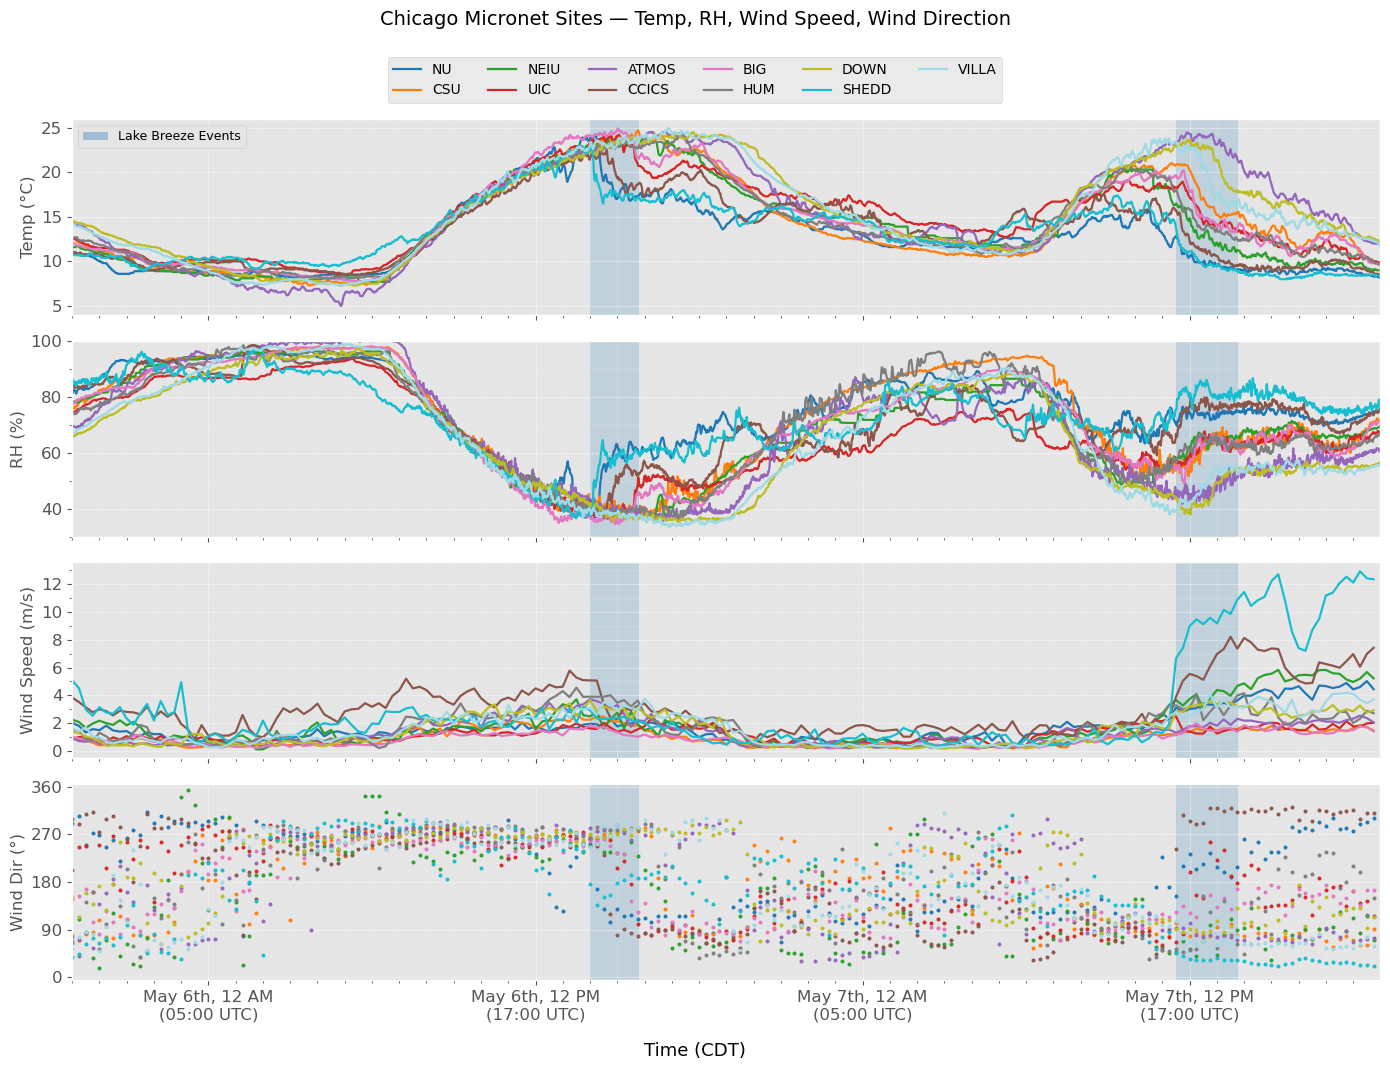

In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from zoneinfo import ZoneInfo  # Python 3.9+
import pandas as pd

# ds = xr.open_dataset("your_file.nc")  # if not already open
plt.style.use('ggplot')

# --- Resampling: ONLY wind gets scalar means (your intervals) ---
spd20  = ds["wind_mean_10s"].resample(time="15min").mean()
wdir15 = ds["wind_dir_10s"].resample(time="15min").mean()

# Temperature & RH at native resolution
temp = ds["temperature"]
rh   = ds["humidity"]

# --- Build Central time indices (assumes source time is UTC or naive-UTC) ---
def to_central_index(xr_time):
    idx = xr_time.to_index()
    if idx.tz is None:
        idx = idx.tz_localize("UTC")
    return idx.tz_convert("America/Chicago")

t_time    = to_central_index(temp.time)
rh_time   = to_central_index(rh.time)
spd_time  = to_central_index(spd20.time)
wdir_time = to_central_index(wdir15.time)

# --- Global time bounds (actual data span) ---
idx_list = [i for i in [t_time, rh_time, spd_time, wdir_time] if len(i) > 0]
t_min = min(i.min() for i in idx_list)
t_max = max(i.max() for i in idx_list)

# --- Color map for sites (consistent color across panels) ---
sites = list(ds.site.values)
sites = [s.item() if hasattr(s, "item") else s for s in sites]
n_sites = len(sites)

if n_sites <= 20:
    cmap_sites = plt.get_cmap("tab20", n_sites)
    site_color = {s: cmap_sites(i) for i, s in enumerate(sites)}
else:
    cmap_sites = plt.get_cmap("viridis")
    norm_sites = mpl.colors.Normalize(vmin=0, vmax=max(1, n_sites-1))
    site_color = {s: cmap_sites(norm_sites(i)) for i, s in enumerate(sites)}

# --- Plot: 4 stacked panels, ALL SITES overlaid on each panel ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axT, axRH, axWS, axWD = axes

handles, labels = [], []
for s in ds.site.values:
    s_key = s.item() if hasattr(s, "item") else s
    color = site_color[s_key]

    ln, = axT.plot(t_time,  temp.sel(site=s).to_numpy(), lw=1.6, color=color)
    axRH.plot(rh_time,     rh.sel(site=s).to_numpy(),    lw=1.6, color=color)
    axWS.plot(spd_time,    spd20.sel(site=s).to_numpy(), lw=1.6, color=color)
    axWD.plot(
        wdir_time, wdir15.sel(site=s).to_numpy(),
        linestyle="None", marker=".", markersize=3.8, color=color, alpha=0.95
    )

    handles.append(ln); labels.append(str(s_key))

# Exact bounds + no padding
for ax in axes:
    ax.set_xlim(t_min, t_max)
    ax.margins(x=0)

# ---------- Major ticks ONLY at 12 AM and 12 PM (local), minors hourly ----------
tz_central = ZoneInfo("America/Chicago")
major_loc = mdates.HourLocator(byhour=[0, 12], tz=tz_central)   # labeled
minor_loc = mdates.HourLocator(interval=1, tz=tz_central)       # unlabeled grid

# ---------- Formatter: Central (12-hour with ordinal day) + UTC beneath ----------
def _ordinal(n: int) -> str:
    if 10 <= n % 100 <= 13:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

def dual_time_formatter(x, pos):
    dt_utc = mdates.num2date(x, tz=ZoneInfo("UTC"))
    dt_loc = dt_utc.astimezone(tz_central)
    mon    = dt_loc.strftime("%b")
    day    = _ordinal(dt_loc.day)
    hr12   = (dt_loc.hour % 12) or 12
    ampm   = "AM" if dt_loc.hour < 12 else "PM"
    top    = f"{mon} {day}, {hr12} {ampm}"
    bottom = dt_utc.strftime("%H:%M")
    return f"{top}\n({bottom} UTC)"

fmt_major = FuncFormatter(dual_time_formatter)

for ax in axes:
    ax.xaxis.set_major_locator(major_loc)
    ax.xaxis.set_minor_locator(minor_loc)
    ax.xaxis.set_major_formatter(fmt_major)
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.15)
    ax.tick_params(labelsize=12)

# -------- Y axes --------
axT.set_ylabel("Temp (°C)", fontsize=12)

axRH.set_ylabel("RH (%)", fontsize=12)
axRH.set_ylim(30, 100)
axRH.yaxis.set_major_locator(MultipleLocator(20))
axRH.yaxis.set_minor_locator(MultipleLocator(10))

axWS.set_ylabel("Wind Speed (m/s)", fontsize=12)  # units per dataset
axWS.yaxis.set_major_locator(MultipleLocator(2))
axWS.yaxis.set_minor_locator(MultipleLocator(1))
axWS.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

axWD.set_ylabel("Wind Dir (°)", fontsize=12)
axWD.set_yticks([0, 90, 180, 270, 360])
axWD.set_ylim(-5, 365)

# Centered x-label
fig.supxlabel("Time (CDT)", fontsize=13)

# Legend + title (site legend)
fig.legend(handles, labels, ncol=min(6, len(labels)), loc="upper center",
           bbox_to_anchor=(0.5, 1.02), fontsize=10)
fig.suptitle("Chicago Micronet Sites — Temp, RH, Wind Speed, Wind Direction", fontsize=14, y=1.06)

# ================== Detect ≥2.5°C drops over 30 minutes ==================
TEMP_DROP_C = 2.5  # threshold

# 1) Resample temperature to 30-min means
temp30 = temp.resample(time="30min").mean(skipna=True)

# 2) Consecutive 30-min change (end - start); drops are negative
dtemp30 = temp30.diff("time")

# 3) Keep only drops whose magnitude is ≥ TEMP_DROP_C (i.e., <= -2.5)
drops = dtemp30.where(dtemp30 <= -TEMP_DROP_C)

# 4) Build events table (UTC + Central) with magnitudes, then print chronologically
events = []
for s in temp30.site.values:
    s_key = s.item() if hasattr(s, "item") else s
    sel = drops.sel(site=s).dropna("time", how="any")  # DataArray of drops ≤ -TEMP_DROP_C
    if sel.size == 0:
        continue

    utc_idx = sel.time.to_index()
    if utc_idx.tz is None:
        utc_idx = utc_idx.tz_localize("UTC")

    for t_utc, mag in zip(utc_idx, sel.values):
        t_loc = t_utc.tz_convert("America/Chicago")
        events.append({
            "site": str(s_key),
            "time_utc": t_utc,
            "time_central": t_loc,
            "drop_C": float(mag)  # negative value
        })

events_df = pd.DataFrame(events).sort_values(["time_central", "site"]).reset_index(drop=True)

# ------- PRINT: chronological occurrences (Central time), grouped by time -------
if events_df.empty:
    print("\nNo detections found.")
else:
    print("\nDetections (chronological, Central time):")
    for t_loc, grp in events_df.groupby("time_central"):
        sites_str = ", ".join(grp["site"])
        max_drop = grp["drop_C"].min()  # most negative is largest drop
        print(f"{t_loc.strftime('%Y-%m-%d %H:%M %Z')}: {sites_str}  (min drop {max_drop:.1f}°C)")

# 5) SHADED WINDOWS per local day: from first event to last event + 30 min
if not events_df.empty:
    # group by local *date*
    day_groups = events_df.groupby(events_df["time_central"].dt.date).agg(
        start=("time_central", "min"),
        end=("time_central", "max"),
    )
    # extend end by +30 minutes
    day_groups["end"] = day_groups["end"] + pd.Timedelta(minutes=45)

    # exactly two colors (alternate if >2 days)
    BLUE  = "#1f77b4"
    GREEN = "#2ca02c"
    day_dates = sorted(day_groups.index)  # chronological
    colors_day = {d: (BLUE if i % 2 == 0 else BLUE) for i, d in enumerate(day_dates)}

    # draw shaded spans on ALL axes
    # draw shaded spans on ALL axes (single blue legend entry)
    for d in day_dates:
        start = day_groups.loc[d, "start"]
        end   = day_groups.loc[d, "end"]
        for ax in axes:
            ax.axvspan(start, end, color=BLUE, alpha=0.18, zorder=0)

    # single legend patch explaining shaded windows
    lb_patch = Patch(facecolor=BLUE, alpha=0.35, edgecolor="none", label="Lake Breeze Events")
    axT.legend(handles=[lb_patch], loc="upper left", fontsize=9, framealpha=0.9)

# ===============================================================================
fig.tight_layout()
plt.show()


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from zoneinfo import ZoneInfo
import pandas as pd

def plot_micronet_four_panel(
    ds: xr.Dataset,
    *,
    tz: str = "America/Chicago",
    style: str = "ggplot",
    wind_resample: str = "15min",
    var_temp: str = "temperature",
    var_rh: str = "humidity",
    var_wspd: str = "wind_mean_10s",
    var_wdir: str = "wind_dir_10s",
    wind_speed_units: str = "m/s",
    title: str = "Chicago Micronet Sites — Temp, RH, Wind Speed, Wind Direction",
    x_label: str = "Time (CDT/CST)",
    figsize=(14, 10),
):
    """
    Create a 4-panel plot (Temp, RH, Wind Speed, Wind Direction) for all sites in `ds`.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset with dims (time, site) and variables listed below.
    tz : str
        IANA timezone for local display (e.g., "America/Chicago").
    style : str
        Matplotlib style to apply (e.g., "ggplot").
    wind_resample : str
        Resampling step for plotting wind speed/direction (e.g., "15min").
    var_temp, var_rh, var_wspd, var_wdir : str
        Variable names in `ds` for temperature, humidity, 10s wind speed, 10s wind dir.
    wind_speed_units : str
        Label for wind speed axis units.
    title : str
        Figure suptitle.
    x_label : str
        Figure x-axis label text.
    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : np.ndarray of Axes (shape=(4,))
    extras : dict
        {
          "site_color": dict(site -> RGBA),
          "t_min": pd.Timestamp (tz-aware, local),
          "t_max": pd.Timestamp (tz-aware, local),
          "local_index": dict with local time indices for each series
        }
    """
    # ---- style ----
    if style:
        plt.style.use(style)

    # ---- helpers ----
    tzinfo = ZoneInfo(tz)
# This function will convert 
    def to_local_index(xr_time):
        idx = xr_time.to_index()
        if idx.tz is None:
            idx = idx.tz_localize("UTC")
        return idx.tz_convert(tz)

    def _ordinal(n: int) -> str:
        if 10 <= n % 100 <= 13:
            suffix = "th"
        else:
            suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
        return f"{n}{suffix}"

    def dual_time_formatter(x, pos):
        dt_utc = mdates.num2date(x, tz=ZoneInfo("UTC"))
        dt_loc = dt_utc.astimezone(tzinfo)
        mon    = dt_loc.strftime("%b")
        day    = _ordinal(dt_loc.day)
        hr12   = (dt_loc.hour % 12) or 12
        ampm   = "AM" if dt_loc.hour < 12 else "PM"
        top    = f"{mon} {day}, {hr12} {ampm}"
        bottom = dt_utc.strftime("%H:%M")
        return f"{top}\n({bottom} UTC)"

    fmt_major = FuncFormatter(dual_time_formatter)

    # ---- series ----
    # wind plotted at a scalar resampled interval
    spd_plot = ds[var_wspd].resample(time=wind_resample).mean()
    wdir_plot = ds[var_wdir].resample(time=wind_resample).mean()
    temp = ds[var_temp]
    rh   = ds[var_rh]

    # local time indices
    t_time    = to_local_index(temp.time)
    rh_time   = to_local_index(rh.time)
    spd_time  = to_local_index(spd_plot.time)
    wdir_time = to_local_index(wdir_plot.time)

    # global bounds (actual data span across plotted series)
    idx_list = [i for i in [t_time, rh_time, spd_time, wdir_time] if len(i) > 0]
    if not idx_list:
        raise ValueError("No time-series data found to plot.")
    t_min = min(i.min() for i in idx_list)
    t_max = max(i.max() for i in idx_list)

    # site colors
    sites = list(ds.site.values)
    sites = [s.item() if hasattr(s, "item") else s for s in sites]
    n_sites = len(sites)
    if n_sites <= 20:
        cmap_sites = plt.get_cmap("tab20", n_sites)
        site_color = {s: cmap_sites(i) for i, s in enumerate(sites)}
    else:
        cmap_sites = plt.get_cmap("viridis")
        norm_sites = mpl.colors.Normalize(vmin=0, vmax=max(1, n_sites-1))
        site_color = {s: cmap_sites(norm_sites(i)) for i, s in enumerate(sites)}

    # ---- figure & axes ----
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)
    axT, axRH, axWS, axWD = axes

    # plot all sites
    handles, labels = [], []
    for s in ds.site.values:
        s_key = s.item() if hasattr(s, "item") else s
        color = site_color[s_key]

        ln, = axT.plot(t_time,  temp.sel(site=s).to_numpy(), lw=1.6, color=color)
        axRH.plot(rh_time,      rh.sel(site=s).to_numpy(),   lw=1.6, color=color)
        axWS.plot(spd_time,     spd_plot.sel(site=s).to_numpy(), lw=1.6, color=color)
        axWD.plot(
            wdir_time, wdir_plot.sel(site=s).to_numpy(),
            linestyle="None", marker=".", markersize=3.8, color=color, alpha=0.95
        )

        handles.append(ln); labels.append(str(s_key))

    # exact bounds + no padding
    for ax in axes:
        ax.set_xlim(t_min, t_max)
        ax.margins(x=0)

    # ticks/formatting
    major_loc = mdates.HourLocator(byhour=[0, 12], tz=tzinfo)   # labeled at midnight & noon
    minor_loc = mdates.HourLocator(interval=1, tz=tzinfo)       # unlabeled hourly grid

    for ax in axes:
        ax.xaxis.set_major_locator(major_loc)
        ax.xaxis.set_minor_locator(minor_loc)
        ax.xaxis.set_major_formatter(fmt_major)
        ax.grid(True, which="major", alpha=0.35)
        ax.grid(True, which="minor", alpha=0.15)
        ax.tick_params(labelsize=12)

    # y-axes
    axT.set_ylabel("Temp (°C)", fontsize=12)

    axRH.set_ylabel("RH (%)", fontsize=12)
    axRH.set_ylim(30, 100)
    axRH.yaxis.set_major_locator(MultipleLocator(20))
    axRH.yaxis.set_minor_locator(MultipleLocator(10))

    axWS.set_ylabel(f"Wind Speed ({wind_speed_units})", fontsize=12)
    axWS.yaxis.set_major_locator(MultipleLocator(2))
    axWS.yaxis.set_minor_locator(MultipleLocator(1))
    axWS.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

    axWD.set_ylabel("Wind Dir (°)", fontsize=12)
    axWD.set_yticks([0, 90, 180, 270, 360])
    axWD.set_ylim(-5, 365)

    # x label, legend, title
    fig.supxlabel(x_label, fontsize=13)
    fig.legend(handles, labels, ncol=min(6, len(labels)), loc="upper center",
               bbox_to_anchor=(0.5, 1.02), fontsize=10)
    fig.suptitle(title, fontsize=14, y=1.06)

    fig.tight_layout()

    extras = {
        "site_color": site_color,
        "t_min": t_min,
        "t_max": t_max,
        "local_index": {
            "temp": t_time, "rh": rh_time, "wspd": spd_time, "wdir": wdir_time
        }
    }
    return fig, axes, extras


(<Figure size 1400x1000 with 4 Axes>,
 array([<Axes: ylabel='Temp (°C)'>, <Axes: ylabel='RH (%)'>,
        <Axes: ylabel='Wind Speed (m/s)'>, <Axes: ylabel='Wind Dir (°)'>],
       dtype=object),
 {'site_color': {'NU': (np.float64(0.12156862745098039),
    np.float64(0.4666666666666667),
    np.float64(0.7058823529411765),
    np.float64(1.0)),
   'CSU': (np.float64(1.0),
    np.float64(0.4980392156862745),
    np.float64(0.054901960784313725),
    np.float64(1.0)),
   'NEIU': (np.float64(0.17254901960784313),
    np.float64(0.6274509803921569),
    np.float64(0.17254901960784313),
    np.float64(1.0)),
   'UIC': (np.float64(0.8392156862745098),
    np.float64(0.15294117647058825),
    np.float64(0.1568627450980392),
    np.float64(1.0)),
   'ATMOS': (np.float64(0.5803921568627451),
    np.float64(0.403921568627451),
    np.float64(0.7411764705882353),
    np.float64(1.0)),
   'CCICS': (np.float64(0.5490196078431373),
    np.float64(0.33725490196078434),
    np.float64(0.29411764705882

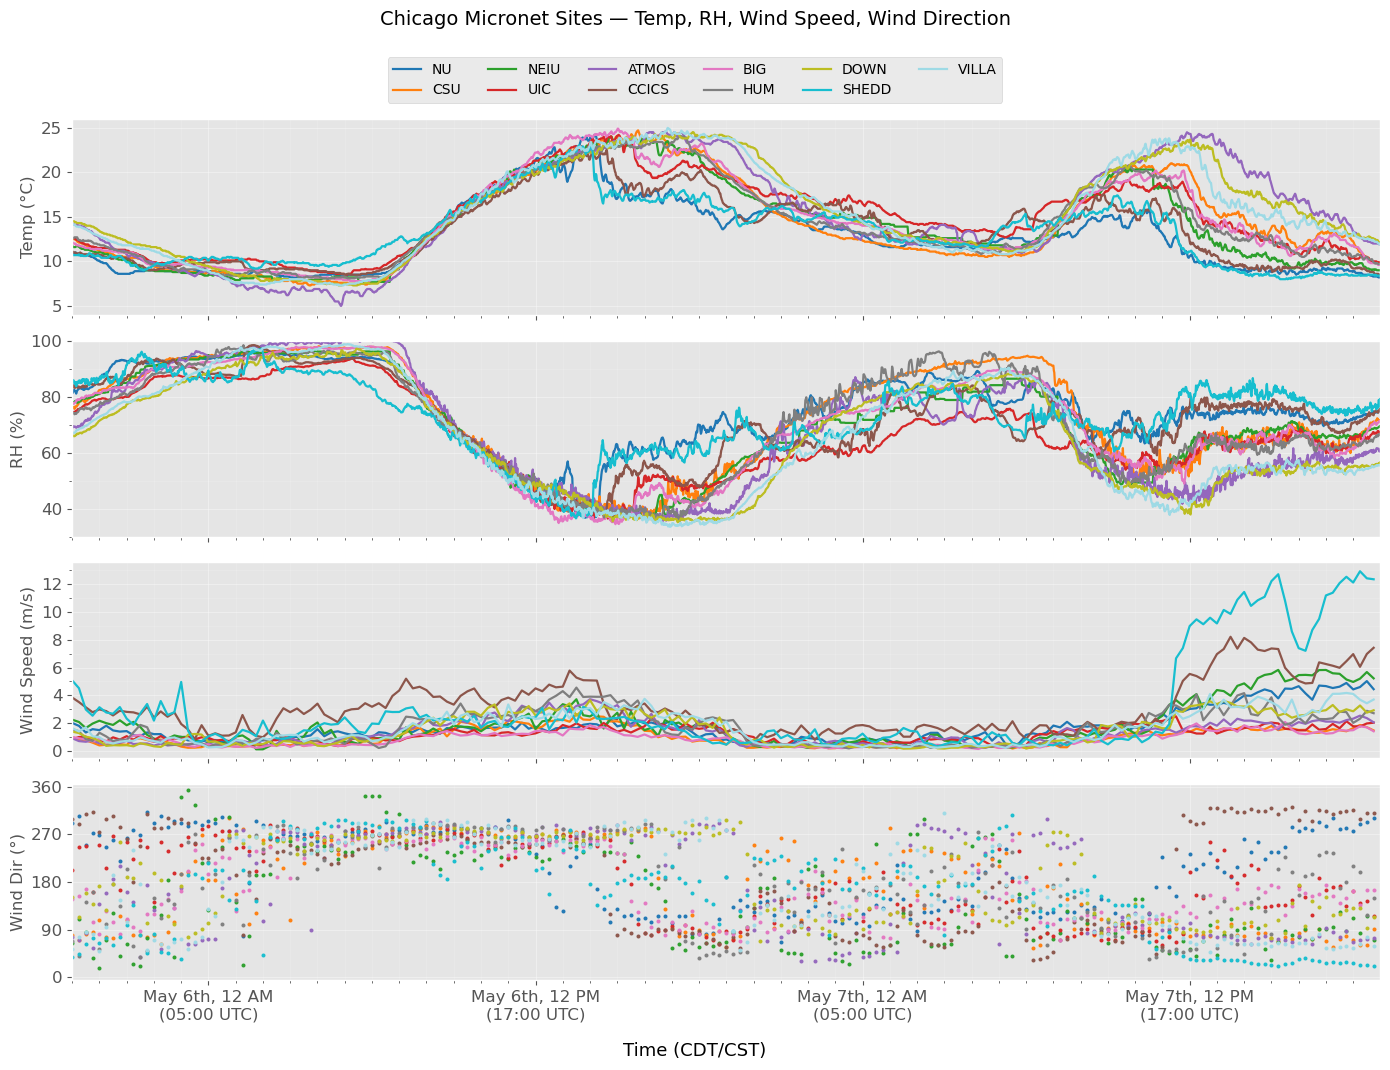

In [20]:
plot_micronet_four_panel(ds)

In [ ]:
import xarray as xr                   
import numpy as np                     
import pandas as pd                    
import matplotlib.pyplot as plt         
import matplotlib.dates as mdates       
import matplotlib as mpl                
from matplotlib.ticker import MultipleLocator, FuncFormatter   
from zoneinfo import ZoneInfo           

def micronet_four_panel(
    ds,
    vars4=("temperature", "humidity", "wind_mean_10s", "wind_dir_10s"),  # top→bottom variables
    *,
    tz="America/Chicago",                 # display timezone for x-axis labels
    title="Micronet — 4-Panel",           # figure title
    x_label="Time (local)",               # shared x label
    wind_resample="15min",                # resample interval for wind-like variables
    style="ggplot",                       # matplotlib style
):
    """
    Plot a simple, consistent 4-panel time-series view across all sites.

    Panels (top→bottom) are chosen by `vars4`. Common meteorological variables get
    sensible default labels/units and light axis niceties (e.g., wind dir ticks).

    Parameters
    ----------
    ds : (xarray.Dataset | str | bytes)
        Dataset (or path) with dimensions (time, site) and the variables named in `vars4`.
        Timestamps should be UTC or naive-UTC (treated as UTC). Each variable is 2-D (time, site).
    vars4 : tuple[str, str, str, str]
        Variables to plot in order (top→bottom). Defaults to
        ("temperature", "humidity", "wind_mean_10s", "wind_dir_10s").
    tz : str
        IANA timezone for local display (e.g., "America/Chicago").
    title : str
        Figure title string.
    x_label : str
        Shared x-axis label at the figure bottom.
    wind_resample : str
        Resample interval for wind-like variables ("wind", "wdir", "wspd") for cleaner visuals.
    style : str | None
        Matplotlib style to apply (e.g., "ggplot"). Set to None to skip.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    axes : np.ndarray[matplotlib.axes.Axes]
        Array of 4 axes corresponding to the requested panels.

    Notes
    -----
    • Wind speed label is **m/s**; humidity **%**; wind direction **°**; pressure **hPa**;
      temperature **°C**. Other variables use their name prettified (underscores → spaces,
      first letter capitalized).
    • All sites are overlaid on each panel with a consistent per-site color.
    """
    # ---------- Accept path-like input ----------
    if isinstance(ds, (str, bytes)):      # allow passing a filepath instead of a Dataset
        ds = xr.open_dataset(ds)          # lazily open the dataset from disk

    # ---------- Optional global style ----------
    if style:                             # apply a style globally if requested
        plt.style.use(style)

    tzinfo = ZoneInfo(tz)                 # timezone object for repeated use

    # ---------- Helpers ----------
    def to_local_index(xr_time):
        """Convert xarray time coord to tz-aware pandas index in `tz`. Treat naive as UTC."""
        idx = xr_time.to_index()          # convert xarray time coordinate to pandas index
        if idx.tz is None:                # if naive timestamps…
            idx = idx.tz_localize("UTC")  # …assume UTC
        return idx.tz_convert(tz)         # convert to the desired local timezone

    def _ordinal(n):
        """Return ordinal string (1→'1st', 2→'2nd', 3→'3rd', else 'th')."""
        return f"{n}{'th' if 10 <= n % 100 <= 13 else {1:'st',2:'nd',3:'rd'}.get(n % 10, 'th')}"

    def dual_time_formatter(x, _pos):
        """
        Major tick label with two lines:
        1) Local time like 'Aug 14, 3 PM'
        2) UTC time like '(20:00 UTC)'
        """
        dt_utc = mdates.num2date(x, tz=ZoneInfo("UTC"))    # axis float → aware UTC datetime
        dt_loc = dt_utc.astimezone(tzinfo)                 # convert to local TZ
        top  = f"{dt_loc.strftime('%b')} {_ordinal(dt_loc.day)}, {(dt_loc.hour % 12) or 12} {'AM' if dt_loc.hour < 12 else 'PM'}"
        bot  = dt_utc.strftime("%H:%M")                    # HH:MM in UTC
        return f"{top}\n({bot} UTC)"                       # two-line label
    fmt_major = FuncFormatter(dual_time_formatter)         # wrap for mpl API

    # ---------- Label/unit resolver ----------
    def _pretty_name(var: str) -> str:
        """Underscores → spaces; capitalize first letter only."""
        txt = var.replace("_", " ")        # human-friendly variable name
        return txt[:1].upper() + txt[1:]   # capitalize first character

    def _label_for(var: str) -> str:
        """Map common variables to fixed units; else use pretty name."""
        v = var.lower()                    # case-insensitive checks
        if "wind_dir_10s" in v:            # explicit match for your dataset naming
            return "Wind direction (°)"
        if "wind_mean_10s" in v:           # explicit match for wind speed
            return "Wind speed (m/s)"
        if ("humidity" in v) or (v == "rh"):
            return "Humidity (%)"
        if "pressure" in v:
            return "Pressure (hPa)"
        if "temperature" in v:
            return "Temperature (°C)"
        if "dewpoint" in v or "dew_point" in v:
            return "Dew point (°C)"
        return _pretty_name(var)           # fallback: just pretty-print the name

    # ---------- Build series for each panel ----------
    series, indices, labels = [], [], []   # containers for y-data, x-index, y-label
    for v in vars4:                        # loop through requested panel variables
        if v not in ds:                    # ensure variable exists in the dataset
            raise KeyError(f"Variable '{v}' not found in dataset.")
        da = ds[v]                         # DataArray with dims (time, site)
        name_lower = v.lower()             # convenience lowercased name

        # Resample wind-like for readability (avoid over-dense points)
        is_wind_like = any(k in name_lower for k in ("wind", "wdir", "wspd"))
        if is_wind_like:                   # for wind speed / direction family
            da = da.resample(time=wind_resample).mean()  # scalar mean over bins

        series.append(da)                  # store processed series
        indices.append(to_local_index(da.time))          # store tz-aware local index
        labels.append(_label_for(v))       # choose tidy y-axis label with units

    # ---------- Global time bounds ----------
    nonempty = [i for i in indices if len(i) > 0]        # guard empty series
    if not nonempty:                                     # if nothing to plot…
        raise ValueError("No time data available to plot.")
    t_min = min(i.min() for i in nonempty)               # earliest timestamp (local)
    t_max = max(i.max() for i in nonempty)               # latest timestamp (local)

    # ---------- Per-site color map ----------
    sites = [s.item() if hasattr(s, "item") else s for s in ds.site.values]  # ensure scalars
    if len(sites) <= 20:                                  # discrete palette for few sites
        cmap = plt.get_cmap("tab20", len(sites))         # tab20 with fixed number of colors
        site_color = {s: cmap(i) for i, s in enumerate(sites)}  # map site→RGBA
    else:                                                 # continuous palette for many sites
        cmap = plt.get_cmap("viridis")                    # perceptually uniform
        norm = mpl.colors.Normalize(vmin=0, vmax=max(1, len(sites) - 1))
        site_color = {s: cmap(norm(i)) for i, s in enumerate(sites)}

    # ---------- Figure & axes ----------
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)  # 4 vertical panels
    handles, legend_labels = [], []             # for a single, figure-level legend

    # ---------- Plot each panel ----------
    for p, ax in enumerate(axes):              # iterate panels (0..3)
        da = series[p]                         # DataArray(time, site)
        t  = indices[p]                        # pandas.DatetimeIndex (local, tz-aware)
        y_label = labels[p].strip()            # axis label for this panel

        # Use scatter for wind direction (prevents lines across wrap at 0/360)
        is_dir_panel = "direction (°)" in y_label.lower()

        for s in ds.site.values:               # overlay all sites on each panel
            s_key = s.item() if hasattr(s, "item") else s
            color = site_color[s_key]          # consistent site color across panels
            y = da.sel(site=s).to_numpy()      # extract site’s 1-D series for plotting

            if is_dir_panel:                   # scatter markers for wind direction
                ax.plot(t, y,
                        linestyle="None", marker=".", markersize=3.8,
                        color=color, alpha=0.95)
            else:                               # line for other variables
                ln, = ax.plot(t, y, lw=1.6, color=color)
                if p == 0:                      # collect handles only once (top panel)
                    handles.append(ln)
                    legend_labels.append(str(s_key))

        # Y-axis label & per-panel niceties
        ax.set_ylabel(y_label, fontsize=12)     # set the axis label for the panel

        yl = y_label.lower()                    # convenience lowercase
        if "humidity (%)" in yl:                # RH panel tweaks
            ax.set_ylim(30, 100)                # focus on practical RH range
            ax.yaxis.set_major_locator(MultipleLocator(20))  # 30,50,70,90
            ax.yaxis.set_minor_locator(MultipleLocator(10))  # 40,60,80,100
        if "direction (°)" in yl:               # wind direction panel ticks
            ax.set_yticks([0, 90, 180, 270, 360])
            ax.set_ylim(-5, 365)                # slight padding to show 0/360 markers
        if "wind speed (m/s)" in yl:            # wind speed panel ticks/format
            ax.yaxis.set_major_locator(MultipleLocator(2))   # major tick every 2 m/s
            ax.yaxis.set_minor_locator(MultipleLocator(1))   # minor tick every 1 m/s
            ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))  # integer labels

    # ---------- Shared x-axis formatting ----------
    for ax in axes:
        ax.set_xlim(t_min, t_max)               # exact data bounds
        ax.margins(x=0)                         # no extra padding on the sides
        ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12], tz=tzinfo))  # ticks at midnight & noon
        ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1, tz=tzinfo))      # hourly minor grid
        ax.xaxis.set_major_formatter(fmt_major) # two-line major tick labels
        ax.grid(True, which="major", alpha=0.35)  # visible major grid
        ax.grid(True, which="minor", alpha=0.15)  # subtle minor grid
        ax.tick_params(labelsize=12)              # readable tick font size

    # ---------- Figure-level labels/legend ----------
    fig.supxlabel(x_label, fontsize=13)         # centered label beneath all panels
    fig.legend(
        handles,                                # one entry per site (collected on panel 0)
        legend_labels,                          # site names as labels
        ncol=min(6, len(legend_labels)),        # wrap legend nicely into rows
        loc="upper center",                     # place above the subplots
        bbox_to_anchor=(0.5, 1.02),             # anchored slightly above top
        fontsize=10
    )
    fig.suptitle(title, fontsize=14, y=1.06)    # overall title above legend

    fig.tight_layout()                           # final layout to avoid overlaps

    return fig, axes                             # hand back the figure + axes


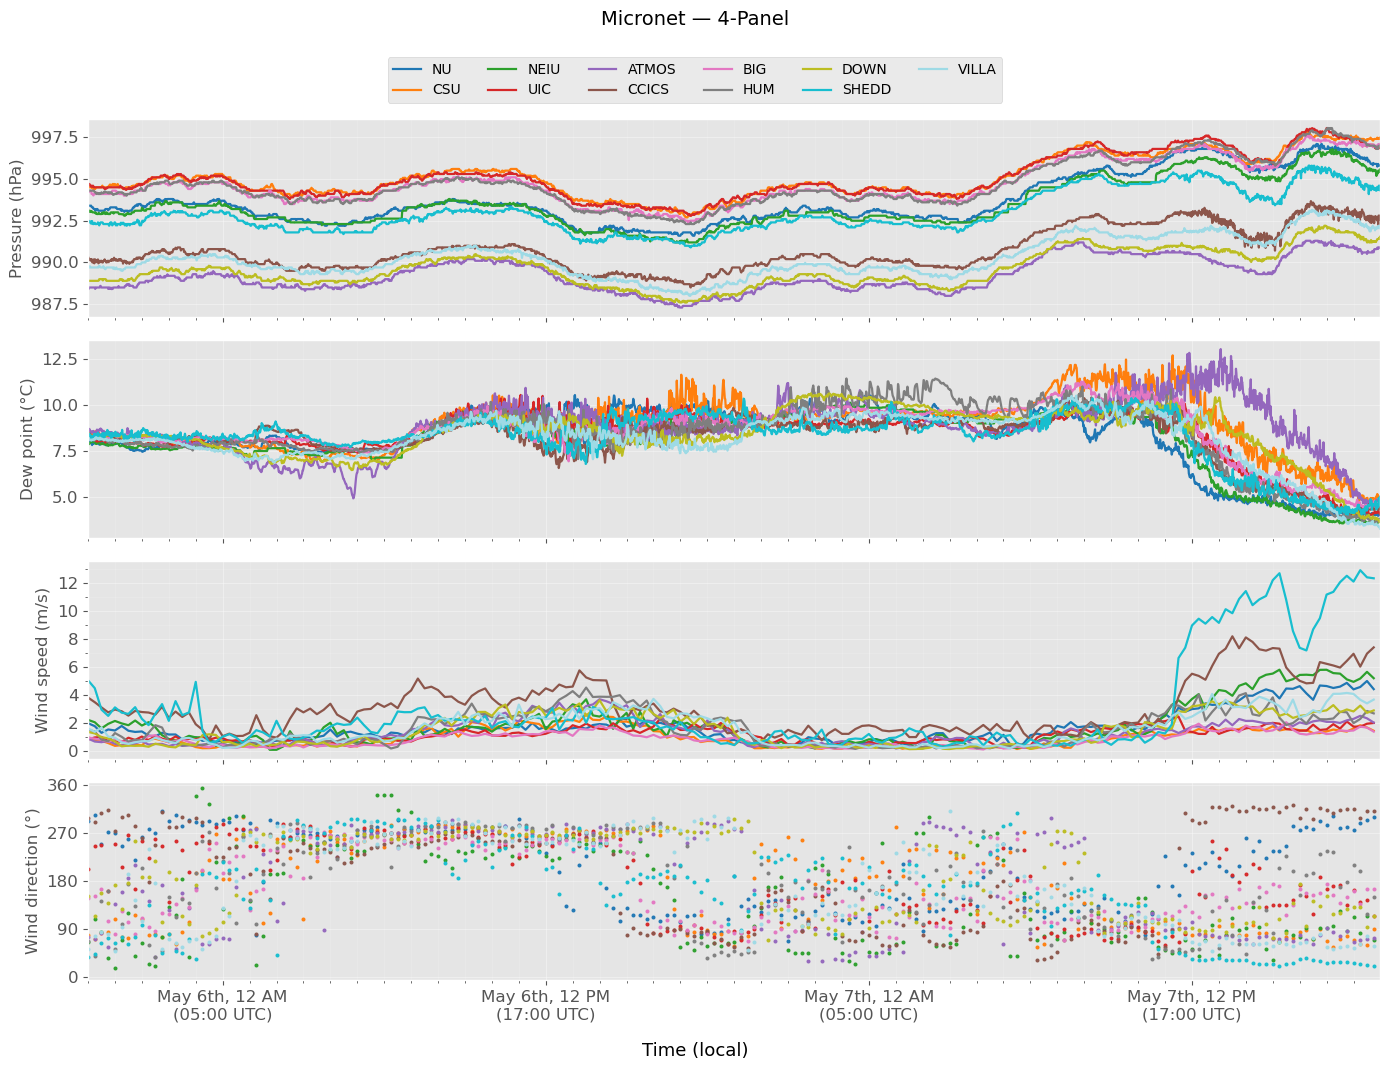

In [32]:
fig, axes = micronet_four_panel(ds, vars4=("pressure","dewpoint","wind_mean_10s","wind_dir_10s"))






